In [1]:
# import sys
# if 'google.colab' in sys.modules:
#     !pip --quiet install open-atmos-jupyter-utils
#     from open_atmos_jupyter_utils import pip_install_on_colab
#     pip_install_on_colab('PyMPDATA-examples')

In [1]:
import numpy as np
import numba
numba.set_num_threads(1)

import matplotlib.pyplot as plt
from open_atmos_jupyter_utils import show_plot, show_anim
import os
os.environ['NUMBA_THREADING_LAYER']='omp'
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions # boundry conditions dla rownan rozniczkowych

In [95]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, bathymetry: np.ndarray, 
                 h_initial: np.ndarray, 
                 uh_initial: np.ndarray|None = None, 
                 vh_initial: np.ndarray|None = None, 
                 options:   Options|None    = None):
        """ initializes the solvers for a given initial condition of `h` at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        if uh_initial is None: uh_initial = np.zeros(grid)
        if vh_initial is None: vh_initial = np.zeros(grid)
        stepper = Stepper(options=options, grid=grid)
        bc_x = boundary_conditions.Constant(value=0)   # left/right walls
        bc_y = boundary_conditions.Extrapolated()      # inflow/outflow in y

        bc = (bc_x, bc_y)  # or [bc_x, bc_y]

        kwargs = {
            'boundary_conditions': bc,
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }
        self.bathymetry = bathymetry

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        if np.amax(np.abs(courant_number)) > 1:
            print("C>1!")
            return 0
        return 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # tuple jest poukladany i niezmienialny, ale moze miec rozne typy w sobie
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        courant_ok = 1

        for it in range(nt + 1): 
            if not courant_ok:
                print(f"At it = {it}")
                break
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    if not courant_ok:
                        break
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    courant_ok = min(self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy), courant_ok)
                    # self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [3]:
def gaussian(x, *, amp=1.0, mu=0.0, sigma=1.0):
    return amp*np.exp(-0.5 * (x-mu)**2 / sigma**2)

In [93]:
class waveRefraction:
    def __init__(self,*,
                 grid:tuple[int,int], 
                 well_center:float|None = None,
                 well_depth:float = 1,
                 well_width:float = 1,
                 wave_center:float|None = None,
                 wave_height:float = 0.025,
                 wave_width:float = 1,
                 H0:float = 1.0,
                 g:float = 10.0
                 ) -> None:
        if H0<=wave_height:
            raise ValueError("Wave fronts cannot exceed 0; H0-wave_height<0")
        X, Y = 0, 1

        if well_center is None:
            well_center = grid[X]//2
        else:
            if well_center>grid[X]:
                raise ValueError("Well center outside of grid")
        if wave_center is None:
            wave_center = grid[X]//4
        else:
            if wave_center>grid[X]:
                raise ValueError("Wave center outside of grid")
        
        self.grid = grid
        self.well_center, self.well_depth, self.well_width = well_center, well_depth, well_width
        self.wave_center, self.wave_height, self.wave_width = wave_center, wave_height, wave_width
        self.H0, self.g = H0, g

        self.xi, self.yi = np.indices(grid)

        self.bathymetry = gaussian(self.xi, amp = self.well_depth, mu = self.well_center, sigma = self.well_width)
        waveshape = gaussian(self.xi, amp = self.wave_height, mu = self.wave_center, sigma = self.wave_width)
        self.h_initial = waveshape + self.bathymetry + self.H0

        u = waveshape * np.sqrt(self.g / self.H0)
        self.uh_initial = self.h_initial * u
        self.vh_initial = np.zeros(grid)
        
    def plot_initial(self):
        fig, axs = plt.subplots(2, 2, figsize = (16,6))
        fields = [self.h_initial, self.bathymetry, self.h_initial - self.bathymetry, self.uh_initial]
        titles = [[r'$h(x,y;t=0)$', r'$b(x,y;t=0)$'],
                  [r'$(h-b)(x,y;t=0)$', r'$\vec v(x,y;t=0)$']]
        nobath = self.h_initial-self.bathymetry
        # print(nobath.min(), nobath.max())
        np.savetxt('bla.csv', self.bathymetry)
        vmin, vmax = self.h_initial.min(), self.h_initial.max()

        cs1 = axs[0,0].contourf(self.h_initial.T, vmin=vmin, vmax = vmax, levels=30)
        axs[0,1].contourf(self.bathymetry.T, vmin=vmin, vmax = vmax, levels=30)
        axs[1,0].contourf(nobath.T, vmin=vmin, vmax = vmax, levels=30)
        axs[1,1].quiver(self.xi.T, self.yi.T, self.uh_initial.T, self.vh_initial.T, scale = 3)
        # axs[:,:].colorbar()
        for i in [0,1]:
            for j in [0,1]:
                # axs[i,j].colorbar()
                axs[i,j].set_title(titles[i][j])
                axs[i,j].set_xlabel(r"$x$")
                axs[i,j].set_ylabel(r"$y$")
                # pass
        plt.tight_layout()
        cbar = fig.colorbar(cs1, ax = axs, location='right')
        cbar.set_label('Field value')

    def run(self,*,
            nt, 
            dt_over_dxy=(.1, .1), 
            outfreq=1
            ):
        pass
    

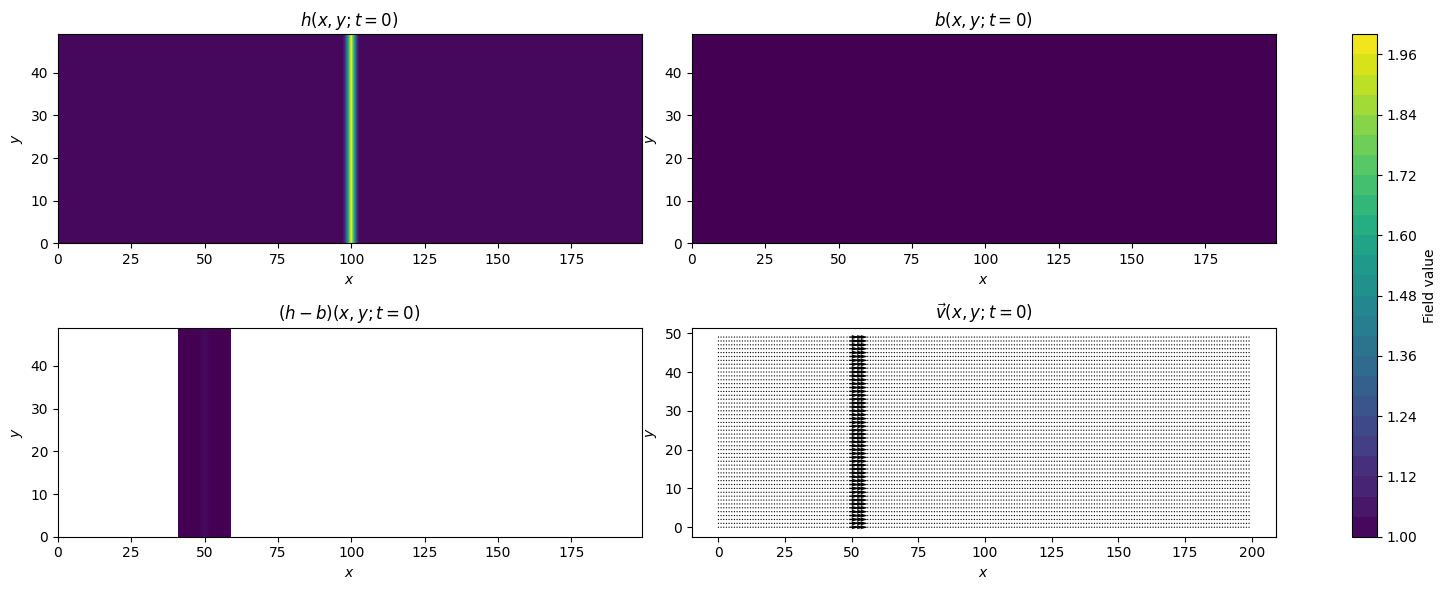

In [94]:
wave = waveRefraction(grid = (200,50))
wave.plot_initial()

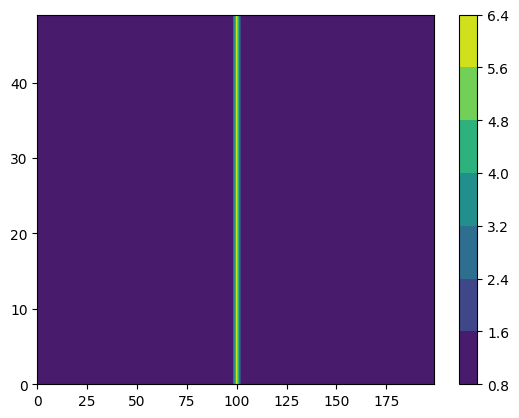

In [13]:
grid = (50, 200)

yi0 = grid[1]//2
sigma_yi = 1
Amp = 5

xi = np.arange(0, grid[0])
yi = np.arange(0, grid[1])
bathymetry = np.ones(grid)
shape = np.exp(- 0.5 * (yi[None,:] - grid[1]//2)**2 / sigma_yi**2)

shape *= -Amp/shape.max()
bathymetry -= shape

plt.contourf(bathymetry)
plt.colorbar()


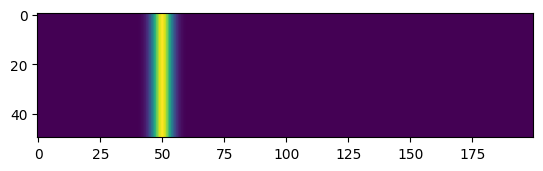

In [15]:
h_initial = bathymetry.copy()
vh_initial = np.zeros(grid)

sigma = 3
H0 = 1.0
g = 10.0
c = np.sqrt(H0 * g)
waveshape_1d = np.exp(- 0.5 * (yi - grid[1]//4)**2 / sigma**2)
waveshape_1d *= 0.1/waveshape_1d.max()
waveshape = np.tile(waveshape_1d, (grid[0],1))
v_y = waveshape * c/H0

# waveshape = np.ones(grid[0]) * 0.2
# waveshape *= 0.2 / waveshape.max()

h_initial += waveshape
vh_initial = h_initial * v_y
# plt.imshow(waveshape)
plt.imshow(h_initial-bathymetry)
# plt.colorbar()

In [6]:
outfreq = 3
output = ShallowWaterEquationsIntegrator(
    h_initial=h_initial, vh_initial=vh_initial, bathymetry=bathymetry
)(
    nt=500, g=g, dt_over_dxy=(.1, .1), outfreq=outfreq
)


In [ ]:
def plot(frame, *, zlim=(-.05, .05)):
    psi = output['h'][frame]-bathymetry
    # xi, yi = np.indices(psi.shape)
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.title(f"t/dt = {frame}")
    # ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
    plt.imshow(psi, vmin = zlim[0], vmax = zlim[1])
    # plt.xlim(100,300)
    plt.colorbar()

    return fig
length = len(output['h'])
show_anim(plot, range(0,length, 1))

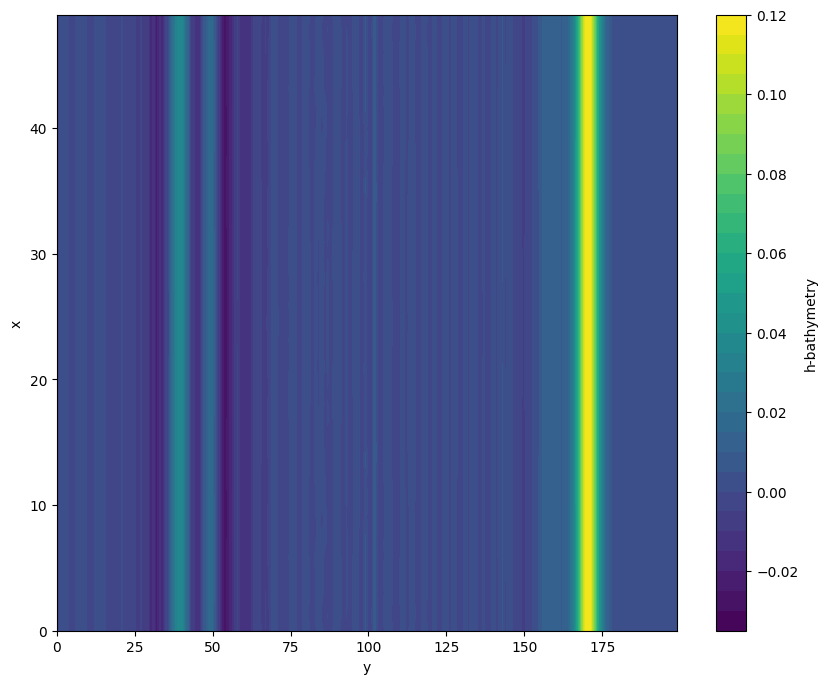

In [15]:
psi = output['h'][-1]-bathymetry
plt.figure(figsize=(10,8))
plt.contourf(psi, cmap='viridis', levels=30)
plt.xlabel("y")
plt.ylabel("x")

cbar = plt.colorbar()
cbar.set_label("h-bathymetry")
plt.savefig("refrakcja.pdf")

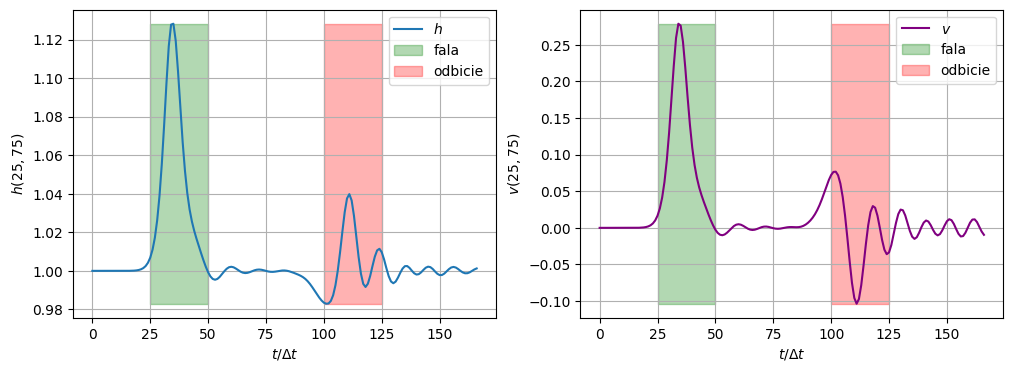

In [35]:
vh = output['vh']
h = output['h']
length = len(vh)
vh_center =np.zeros([length]) 
h_center = np.zeros([length])
for i in range(length):
    vh_center[i] = vh[i][grid[0]//2,75]
    h_center[i] = h[i][grid[0]//2,75]
v_center = vh_center/h_center

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))



ax1.plot(h_center, label='$h$')
ax1.set_xlabel(f"$t/Δ t$")
ax1.set_ylabel(f"$h(25,75)$")
ax1.grid()

ax1.fill_betweenx([h_center.min(), h_center.max()],25,50, alpha=0.3, color = 'green', label = 'fala')
ax1.fill_betweenx([h_center.min(), h_center.max()],100,125, alpha=0.3, color = 'red', label = 'odbicie')
ax1.legend()


ax2.plot(v_center, color='purple', label=f'$v$')
ax2.set_xlabel(f"$t/Δt$")
ax2.set_ylabel(f"$v(25,75)$")
ax2.fill_betweenx([v_center.min(), v_center.max()],25,50, alpha=0.3, color = 'green', label = 'fala')
ax2.fill_betweenx([v_center.min(), v_center.max()],100,125, alpha=0.3, color = 'red', label = 'odbicie')
ax2.legend()
ax2.grid()

